In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import gc

import sys
sys.path.append("..")
from helper_functions_260527 import import_flight_data

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

pd.set_option('display.max_columns',None)

radio_altitude = "radio_altitude"
vertical_acceleration = "vert_acc"

recompute = False
limit = 3140 - 60

In [2]:
# Step 1: Define turbulence data (= labels) ✓
# Step 2: Prepare wind data (= features) ✓
# Step 3: Join flight and wind data ✓
# Step 4: ML model ✓
# Step 5: Input feature ranking, tuning

### Step 1: Define turbulence data (= labels)

In [3]:
def trim_group(g):
    g = g.sort_values("Time (secs)")
    
    # find first index where altitude becomes valid
    valid_idx = g.index[g["radio_altitude"] > 1400]
    
    if len(valid_idx) == 0:
        return g.iloc[0:0]  # empty group
    
    start = valid_idx[0]
    return g.loc[start:]

if recompute:
    path_flights = "/home/jovyan/work/AppliedML/FinalProject/Final_project_data/data/ML_data/NBI/FDM data/"
    df = import_flight_data(data_dir=path_flights,limit=limit,add_source_file=True,filter=False)

    # Remove everything where Radio Altitude > 1500 ft or below 0
    df[radio_altitude] = df[radio_altitude].ffill()
    df = df[df[radio_altitude] <= 1500]
    df = df[df[radio_altitude] >= 0]

    # Remove years before 2024
    df["year"] = df["year"].ffill()
    df = df[df["year"] >= 2024.0]

    # Remove departures, if there are any
    df = df[~df["source_file"].str.contains("Dep",na=False)]

    # For easier readability, introduce landing_id and drop source_file
    df["landing_id"] = pd.factorize(df["source_file"])[0]
    df = df.drop(["source_file"],axis=1)

    # Remove erroneous data points and finally, reset the indices
    df = df.groupby("landing_id", group_keys=False).apply(trim_group)
    df = df.reset_index(drop=True)

    # Calculate how much vertical accelaration deviates from 1
    df['vert_acc_dev'] = abs(df['vert_acc'] - 1.0)
    
    # Calculate std, max and maximum jump of vertical acceleration per landing
    turbulence_per_landing_std = df.groupby("landing_id")["vert_acc_dev"].std()
    turbulence_per_landing_max = df.groupby("landing_id")["vert_acc"].max()
    turbulence_per_landing_max_jump = df.groupby("landing_id")["vert_acc"].apply(lambda x: x.diff().abs().max())

    show_extras = False
    if show_extras:
        for name, group in df.groupby("landing_id"):
            plt.plot(group["radio_altitude"], marker="o", label=name)
        plt.grid()
        plt.legend()
        for file, grp in df.groupby("landing_id"):
            print(grp[["Time (secs)", "radio_altitude"]].head())

### Step 2: Prepare wind data (= labels)

In [4]:
if recompute:
    # Fill all the fields related to time
    times = ["year","month","day","hour","minute","second"]
    df[times] = df[times].ffill()

    # Find out the time when each landing starts
    landing_starts = df.groupby("landing_id").head(1).reset_index(drop=True)
    del df
    
    # Generate the filenames for the corresponding wind data files
    landing_starts["wind_file_name"] = (
        "TWI-" + landing_starts["year"].astype(int).astype(str) + "-" +
        landing_starts["month"].astype(int).astype(str).str.zfill(2) + "-" +
        landing_starts["day"].astype(int).astype(str).str.zfill(2) +
        "_UTC_log.csv"
    )

    # Generate datetime columns to be consistent with wind data
    landing_starts["landing_time"] = pd.to_datetime(
        dict(
            year=landing_starts["year"].astype(int),
            month=landing_starts["month"].astype(int),
            day=landing_starts["day"].astype(int),
            hour=landing_starts["hour"].astype(int),
            minute=landing_starts["minute"].astype(int),
            second=landing_starts["second"].astype(int),
        )
    )

In [5]:
# Part of the code that crashes the kernel

x = False
if recompute and x:
    # Load the wind data
    path_wind = "/home/jovyan/work/AppliedML/FinalProject/Final_project_data/data/ML_data/TWI data/" # eg.: TWI-2024-11-07_UTC_log
    wind_data = {}

    for _, row in landing_starts.iterrows():
        file_path = Path(path_wind)/row["wind_file_name"]
        wind_df = pd.read_csv(file_path,sep=";")
        wind_df["DateTime"] = pd.to_datetime(wind_df["DateTime"])
        wind_data[row["landing_id"]] = wind_df
        del wind_df

In [6]:
# Instrad, try:

if recompute:
    path_wind = "/home/jovyan/work/AppliedML/FinalProject/Final_project_data/data/ML_data/TWI data/"
    wind_data = {}
    for file_name in landing_starts["wind_file_name"].unique():
        file_path = Path(path_wind)/file_name
        wind_df = pd.read_csv(file_path, sep=";")
        wind_df["DateTime"] = pd.to_datetime(wind_df["DateTime"])
        wind_data[file_name] = wind_df

In [7]:
if recompute:
    # Wind variables to use (for now: All of them)
    wind_variables = [
        'W04.VectorMeanWindSpeed',
        'W04.VectorMeanWindDirection',
        'W04.ScalarMaxWindSpeed',
        'W04.ScalarMaxWindAtDirection',
        'W04.ScalarMeanWindSpeed',
        'W04.ScalarWindSpeedDeviation',
        'W04.ScalarMeanWindDirection',
        'W04.ScalarWindDirectionDeviation',
        'W04.LastWindSpeed',
        'W04.LastWindDirection',
        'W22.VectorMeanWindSpeed',
        'W22.VectorMeanWindDirection',
        'W22.ScalarMaxWindSpeed',
        'W22.ScalarMaxWindAtDirection',
        'W22.ScalarMeanWindSpeed',
        'W22.ScalarWindSpeedDeviation',
        'W22.ScalarMeanWindDirection',
        'W22.ScalarWindDirectionDeviation',
        'W22.LastWindSpeed',
        'W22.LastWindDirection']

    # How many minutes to look back
    wind_windows = [60,30,20,10,5]
    feature_rows = []

    for _, landing in landing_starts.iterrows():
        landing_id = landing["landing_id"]
        landing_time = landing["landing_time"]
        wind_df = wind_data[landing["wind_file_name"]] #wind_df = wind_data[landing_id] More memory-friendly?

        features = {"landing_id": landing_id}

        for minutes in wind_windows:
            window_start = landing_time - pd.Timedelta(minutes=minutes)
            window = wind_df[(wind_df["DateTime"] >= window_start) & (wind_df["DateTime"] < landing_time)]
            for col in wind_variables:
                prefix = f"{col}_{minutes}m"
                features[f"{prefix}_mean"] = window[col].mean()
                features[f"{prefix}_std"] = window[col].std()
                features[f"{prefix}_max"] = window[col].max()

        feature_rows.append(features)

    wind_features = pd.DataFrame(feature_rows)

### Step 4: ML model

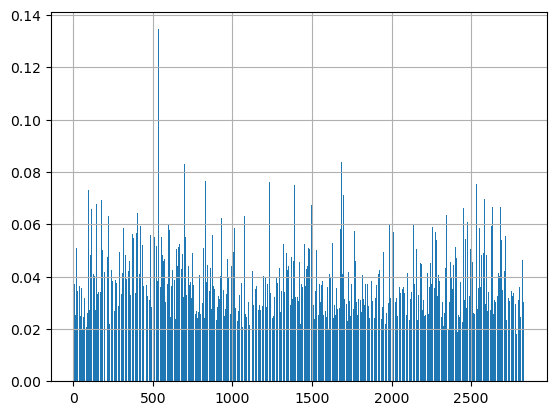

In [8]:
if recompute:
    landing_metrics = pd.concat([
        turbulence_per_landing_std.rename("turbulence_std"),
        turbulence_per_landing_max.rename("turbulence_max"),
        turbulence_per_landing_max_jump.rename("turbulence_max_jump")],axis=1).reset_index()
    DATA = wind_features.merge(landing_metrics,on="landing_id")
    DATA.to_csv("DATA%s.csv" % limit, index=False)
else:
    DATA = pd.read_csv("DATA%s.csv" %limit)

X = DATA.drop(columns=["landing_id","turbulence_std","turbulence_max","turbulence_max_jump"])
y = DATA["turbulence_std"]

plt.bar(DATA["landing_id"],DATA["turbulence_std"])
plt.grid()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)

R²: 0.26350074792210376
RMSE: 0.011017019506733967


In [11]:
importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance.head(20))

                                   feature  importance
107   W22.ScalarWindSpeedDeviation_30m_max    0.059432
26               W04.LastWindSpeed_60m_max    0.056323
47    W22.ScalarWindSpeedDeviation_60m_max    0.055078
105  W22.ScalarWindSpeedDeviation_30m_mean    0.041088
225  W22.ScalarWindSpeedDeviation_10m_mean    0.032158
8           W04.ScalarMaxWindSpeed_60m_max    0.023267
115              W22.LastWindSpeed_30m_std    0.023162
295               W22.LastWindSpeed_5m_std    0.019864
116              W22.LastWindSpeed_30m_max    0.017762
38          W22.ScalarMaxWindSpeed_60m_max    0.015976
45   W22.ScalarWindSpeedDeviation_60m_mean    0.014255
66         W04.ScalarMaxWindSpeed_30m_mean    0.012540
15   W04.ScalarWindSpeedDeviation_60m_mean    0.011937
195  W04.ScalarWindSpeedDeviation_10m_mean    0.010690
60        W04.VectorMeanWindSpeed_30m_mean    0.010623
2          W04.VectorMeanWindSpeed_60m_max    0.009457
137   W04.ScalarWindSpeedDeviation_20m_max    0.009432
167   W22.